In [224]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Kernel, Matern, RBF, WhiteKernel, ConstantKernel as C

import jax.numpy as jnp

from jax import random
from jax.example_libraries import optimizers
from jax import jit, grad, vmap
from jax import tree_util as jtu

import functools

import neural_tangents as nt
from neural_tangents import stax

import math

import torch
import torch.nn as nn
import torch.nn.functional as F
from contextlib import contextmanager


In [42]:
#Plot settings
from IPython.display import set_matplotlib_formats
set_matplotlib_formats('pdf', 'svg')
import matplotlib
import seaborn as sns

sns.set(font_scale=1.3)
sns.set_style("darkgrid", {"axes.facecolor": ".95"})

import matplotlib.pyplot as plt

def format_plot(x=None, y=None):
  # plt.grid(False)
  ax = plt.gca()
  if x is not None:
    plt.xlabel(x, fontsize=20)
  if y is not None:
    plt.ylabel(y, fontsize=20)

def finalize_plot(shape=(1, 1)):
  plt.gcf().set_size_inches(
    shape[0] * 1.5 * plt.gcf().get_size_inches()[1],
    shape[1] * 1.5 * plt.gcf().get_size_inches()[1])
  plt.tight_layout()

legend = functools.partial(plt.legend, fontsize=10)

/var/folders/ld/k3z4_g8n0nvdb_19cpz6t30h0000gn/T/ipykernel_75537/2921474239.py:3: DeprecationWarning: `set_matplotlib_formats` is deprecated since IPython 7.23, directly use `matplotlib_inline.backend_inline.set_matplotlib_formats()`
  set_matplotlib_formats('pdf', 'svg')


In [43]:
def plot_fn(train, test, *fs):
  train_xs, train_ys = train

  plt.plot(train_xs, train_ys, 'ro', markersize=10, label='train')

  if test != None:
    test_xs, test_ys = test
    plt.plot(test_xs, test_ys, 'k--', linewidth=3, label='$f(x)$')

    for f in fs:
      plt.plot(test_xs, f(test_xs), '-', linewidth=3)

  plt.xlim([-jnp.pi, jnp.pi])
  # plt.ylim([-1.5, 1.5])

  format_plot('$x$', '$f(x)$')

In [44]:
key = random.PRNGKey(42)

In [45]:
train_points = 20
test_points = 100
noise_scale = 1e-1

target_fn = lambda x: jnp.sin(2 * jnp.pi * x) +0.5*x

In [46]:
# Generating training data set
# randomly choosen x and noise
# generate random inputs, apply target function and add random noise
key, x_key, y_key = random.split(key, 3)

train_xs = random.uniform(x_key, (train_points, 1), minval=-jnp.pi, maxval=jnp.pi)

train_ys = target_fn(train_xs)
train_ys += noise_scale * random.normal(y_key, (train_points, 1))
train = (train_xs, train_ys)
# print(train)

In [47]:
# Generate test data with shape (N,1)
# treat it as model with one input feature
# extendable to higher dimensions
test_xs = jnp.linspace(-jnp.pi, jnp.pi, test_points)
test_xs = jnp.reshape(test_xs, (test_points, 1))

test_ys = target_fn(test_xs)
test = (test_xs, test_ys)
# print(test)

In [ ]:
# Look at train data
plot_fn(train, test)
legend(loc='upper left')
finalize_plot((0.85, 0.6))

In [264]:
def gp_mean_fn(x):
  x_np = np.array(x)
  mean = gp.predict(x_np, return_std=False)
  return jnp.array(mean).reshape(x.shape[0], 1)

In [221]:
from sklearn.preprocessing import StandardScaler
X_train = np.array(train_xs)
y_train = np.array(train_ys).ravel()

# scaler = StandardScaler()
# X_train_s = scaler.fit_transform(X_train)


# print(X_train_s.min(), X_train_s.max(), X_train_s.std())

kernel = C(1.25, (1.1, 1.4)) * RBF(0.31, (0.28, 0.35)) 

gp = GaussianProcessRegressor(
    kernel=kernel,
    n_restarts_optimizer=100,
    normalize_y=True,
    random_state=0,
    alpha=1e-8
)
gp.fit(X_train, y_train)

print(gp.kernel_)

# Predict on test grid
X_test_np = np.array(test_xs)
# X_test_s  = scaler.transform(X_test_np)
mean_np, std_np = gp.predict(X_test_np, return_std=True)
mean_np = mean_np.reshape(-1, 1)
mean_1d, std_1d = gp.predict(X_test_np, return_std=True)


1.18**2 * RBF(length_scale=0.28)


/opt/anaconda3/envs/nt/lib/python3.10/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__constant_value is close to the specified upper bound 1.4. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/opt/anaconda3/envs/nt/lib/python3.10/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified lower bound 0.28. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


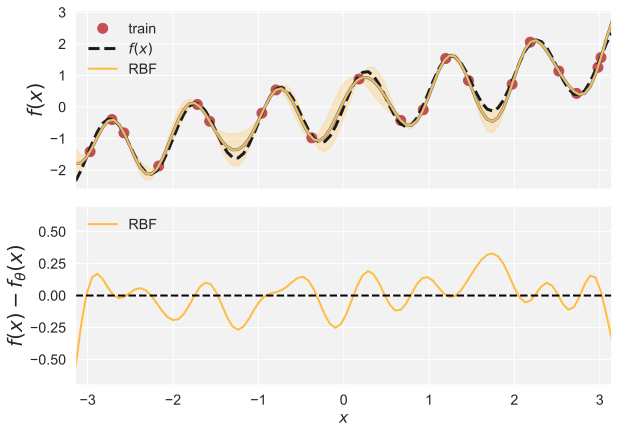

In [222]:
fig, (ax_top, ax_bottom) = plt.subplots(
    2, 1,
    figsize=(5, 7),
    gridspec_kw={'height_ratios': [1, 1]},
    sharex=True
)

plt.sca(ax_top)
plot_fn(train, test, gp_mean_fn)

plt.plot(test_xs, gp_mean_fn(test_xs), '-', linewidth=2, color='#ffbc42', label='RBF')

lo = (mean_1d - std_1d).ravel()
hi = (mean_1d + std_1d).ravel()
plt.fill_between(X_test_np.ravel(), lo, hi, alpha=0.25, color='#ffbc42')

plt.xlim([-jnp.pi, jnp.pi])
plt.legend(loc='upper left', frameon=False)
plt.xlabel(None)
plt.ylabel(r'$f(x)$', fontsize=20)
finalize_plot((0.85, 0.6))


plt.sca(ax_bottom)

residuals_rbf = np.array(test_ys).ravel() - gp_mean_fn(test_xs).ravel()

plt.plot(test_xs, residuals_rbf, '#ffbc42', linewidth=2, label='RBF')

plt.axhline(0, linestyle='--', color='black', linewidth=2)

plt.xlabel('$x$')
plt.ylabel(r'$f(x) - f_\theta(x)$', fontsize=20)
plt.legend(loc='upper left', frameon=False)
plt.ylim([-0.7, 0.7])

plt.tight_layout()
plt.savefig("figs/RBF_kernel.pdf")
plt.show()
plt.close()


In [204]:
X_train = np.array(train_xs)
y_train = np.array(train_ys).ravel()

kernel = C(1.25, (1.1, 1.4)) * Matern(
    length_scale=1.5,
    length_scale_bounds=(1.0, 2.),
    nu=5.  # 0.5=rough, 1.5=moderate, 2.5=smoother, inf -> RBF
)

gp = GaussianProcessRegressor(
    kernel=kernel,
    n_restarts_optimizer=100,
    normalize_y=True,
    random_state=0,
    alpha=1e-8
)
gp.fit(X_train, y_train)

print(gp.kernel_)

# Predict on test grid
X_test_np = np.array(test_xs)
# X_test_s  = scaler.transform(X_test_np)
mean_np, std_np = gp.predict(X_test_np, return_std=True)
mean_np = mean_np.reshape(-1, 1)
mean_1d, std_1d = gp.predict(X_test_np, return_std=True)


1.18**2 * Matern(length_scale=1, nu=5)


/opt/anaconda3/envs/nt/lib/python3.10/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__constant_value is close to the specified upper bound 1.4. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


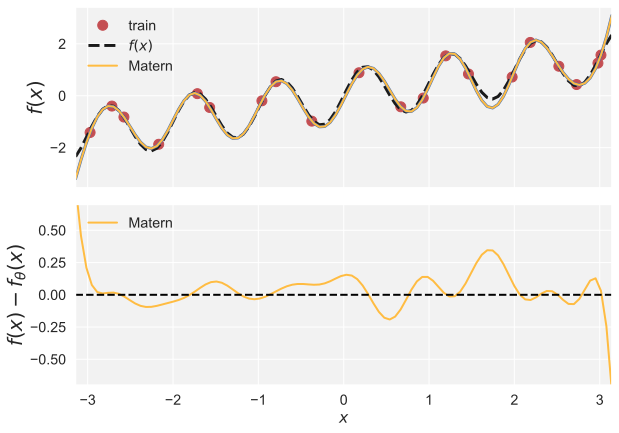

In [205]:
fig, (ax_top, ax_bottom) = plt.subplots(
    2, 1,
    figsize=(5, 7),
    gridspec_kw={'height_ratios': [1, 1]},
    sharex=True
)

plt.sca(ax_top)
plot_fn(train, test, gp_mean_fn)

plt.plot(test_xs, gp_mean_fn(test_xs), '-', linewidth=2, color='#ffbc42', label='Matern')

lo = (mean_1d - std_1d).ravel()
hi = (mean_1d + std_1d).ravel()
plt.fill_between(X_test_np.ravel(), lo, hi, alpha=0.25, color='#ffbc42')

plt.xlim([-jnp.pi, jnp.pi])
plt.legend(loc='upper left', frameon=False)
plt.xlabel(None)
plt.ylabel(r'$f(x)$', fontsize=20)
finalize_plot((0.85, 0.6))


plt.sca(ax_bottom)

residuals_rbf = np.array(test_ys).ravel() - gp_mean_fn(test_xs).ravel()

plt.plot(test_xs, residuals_rbf, '#ffbc42', linewidth=2, label='Matern')

plt.axhline(0, linestyle='--', color='black', linewidth=2)

plt.xlabel('$x$')
plt.ylabel(r'$f(x) - f_\theta(x)$', fontsize=20)
plt.legend(loc='upper left', frameon=False)
plt.ylim([-0.7, 0.7])

plt.tight_layout()
# plt.savefig("figs/RBF_kernel.pdf")
plt.show()
plt.close()


In [243]:
import numpy as np
from sklearn.gaussian_process.kernels import Kernel, Hyperparameter

class GibbsKernel1D(Kernel):
    """
    1D Gibbs (non-stationary RBF) kernel with
        ell(x) = exp(b0 + b1 * x)

    Hyperparameters optimized by sklearn:
        theta = [b0, b1, log_sigma2]
    """

    def __init__(
        self,
        b0=0.0, b1=0.0,
        b0_bounds=(-5.0, 5.0),
        b1_bounds=(-5.0, 5.0),
        sigma2=1.0,
        sigma2_bounds=(1e-3, 1e3),
    ):
        self.b0 = float(b0)
        self.b1 = float(b1)
        self.b0_bounds = b0_bounds
        self.b1_bounds = b1_bounds

        self.sigma2 = float(sigma2)
        self.sigma2_bounds = sigma2_bounds

    # ---- hyperparameter metadata (for sklearn printing etc.)
    @property
    def hyperparameter_b0(self):
        return Hyperparameter("b0", "numeric", self.b0_bounds)

    @property
    def hyperparameter_b1(self):
        return Hyperparameter("b1", "numeric", self.b1_bounds)

    @property
    def hyperparameter_sigma2(self):
        return Hyperparameter("sigma2", "numeric", self.sigma2_bounds)

    # ---- explicit theta and bounds to guarantee finiteness
    @property
    def theta(self):
        # sklearn optimizes theta in R^n; we log-transform sigma2
        return np.array([self.b0, self.b1, np.log(self.sigma2)])

    @theta.setter
    def theta(self, theta):
        self.b0 = float(theta[0])
        self.b1 = float(theta[1])
        self.sigma2 = float(np.exp(theta[2]))

    @property
    def bounds(self):
        # bounds must be finite; log-space for sigma2
        return np.array([
            self.b0_bounds,
            self.b1_bounds,
            np.log(self.sigma2_bounds)
        ])

    # ---- kernel internals
    def _ell(self, X):
        x = X[:, 0]
        return np.exp(self.b0 + self.b1 * x)

    def __call__(self, X, Y=None, eval_gradient=False):
        X = np.atleast_2d(X)
        if X.shape[1] != 1:
            raise ValueError("GibbsKernel1D only supports 1D inputs (n,1).")

        if Y is None:
            Y = X
        else:
            Y = np.atleast_2d(Y)
            if Y.shape[1] != 1:
                raise ValueError("GibbsKernel1D only supports 1D inputs (m,1).")

        x = X[:, 0][:, None]
        y = Y[:, 0][None, :]

        ell_x = self._ell(X)[:, None]
        ell_y = self._ell(Y)[None, :]

        ell2_x = ell_x ** 2
        ell2_y = ell_y ** 2
        denom = ell2_x + ell2_y

        diff2 = (x - y) ** 2

        prefactor = np.sqrt(2.0 * ell_x * ell_y / denom)
        exponent = np.exp(-diff2 / denom)

        K = self.sigma2 * prefactor * exponent

        if not eval_gradient:
            return K

        # ---- gradients wrt theta = [b0, b1, log_sigma2]
        d_ellx_db0 = ell_x
        d_elly_db0 = ell_y
        d_ellx_db1 = ell_x * x
        d_elly_db1 = ell_y * y

        def dlogK(d_ellx, d_elly):
            d_denom = 2 * ell_x * d_ellx + 2 * ell_y * d_elly
            term_pref = 0.5 * (d_ellx / ell_x + d_elly / ell_y - d_denom / denom)
            term_exp = diff2 * d_denom / (denom ** 2)
            return term_pref + term_exp

        dlogK_db0 = dlogK(d_ellx_db0, d_elly_db0)
        dlogK_db1 = dlogK(d_ellx_db1, d_elly_db1)

        dK_db0 = K * dlogK_db0
        dK_db1 = K * dlogK_db1
        dK_dlogsigma2 = K  # because d/dlog(sigma2) = sigma2 * d/dsigma2

        grad = np.stack([dK_db0, dK_db1, dK_dlogsigma2], axis=2)
        return K, grad

    def diag(self, X):
        return np.full(X.shape[0], self.sigma2)

    def is_stationary(self):
        return False


In [265]:
X_train = np.array(train_xs).reshape(-1, 1)
y_train = np.array(train_ys).ravel()
X_test  = np.array(test_xs).reshape(-1, 1)

kernel = GibbsKernel1D(
    b0=1e7, b1=-1e-3,          # initial log-lengthscale params
    sigma2=2.0
)

gp = GaussianProcessRegressor(
    kernel=kernel,
    n_restarts_optimizer=20,
    alpha=1e-8,
    normalize_y=True,
    random_state=0
)

gp.fit(X_train, y_train)

print(gp.kernel_)

# Predict on test grid
X_test_np = np.array(test_xs)
# X_test_s  = scaler.transform(X_test_np)
mean_np, std_np = gp.predict(X_test_np, return_std=True)
mean_np = mean_np.reshape(-1, 1)
mean_1d, std_1d = gp.predict(X_test_np, return_std=True)


GibbsKernel1D(-2.27, 5, 0.393)


/opt/anaconda3/envs/nt/lib/python3.10/site-packages/sklearn/gaussian_process/_gpr.py:663: ConvergenceWarning: lbfgs failed to converge after 15 iteration(s) (status=2):
ABNORMAL_TERMINATION_IN_LNSRCH

You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  _check_optimize_result("lbfgs", opt_res)
/opt/anaconda3/envs/nt/lib/python3.10/site-packages/sklearn/gaussian_process/_gpr.py:663: ConvergenceWarning: lbfgs failed to converge after 11 iteration(s) (status=2):
ABNORMAL_TERMINATION_IN_LNSRCH

You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  _check_optimize_result("lbfgs", opt_res)
/opt/anaconda3/envs/nt/lib/python3.10/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 0 of parameter b1 is close to the specified upper bound 5.0. Increasing the bound and calling fit again may find a better value.
  wa

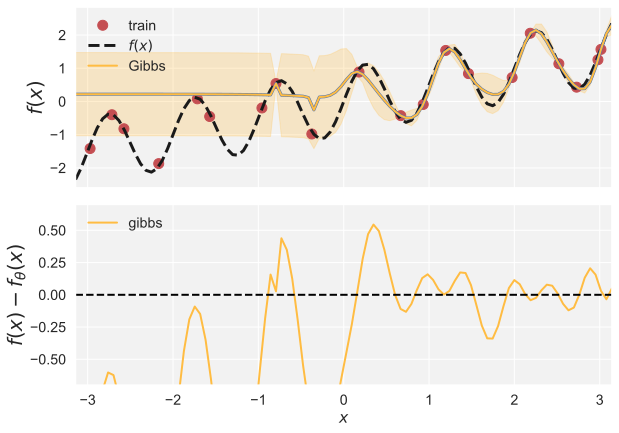

In [266]:
fig, (ax_top, ax_bottom) = plt.subplots(
    2, 1,
    figsize=(5, 7),
    gridspec_kw={'height_ratios': [1, 1]},
    sharex=True
)

plt.sca(ax_top)
plot_fn(train, test, gp_mean_fn)

plt.plot(test_xs, gp_mean_fn(test_xs), '-', linewidth=2, color='#ffbc42', label='Gibbs')

lo = (mean_1d - std_1d).ravel()
hi = (mean_1d + std_1d).ravel()
plt.fill_between(X_test_np.ravel(), lo, hi, alpha=0.25, color='#ffbc42')

plt.xlim([-jnp.pi, jnp.pi])
plt.legend(loc='upper left', frameon=False)
plt.xlabel(None)
plt.ylabel(r'$f(x)$', fontsize=20)
finalize_plot((0.85, 0.6))


plt.sca(ax_bottom)

residuals_rbf = np.array(test_ys).ravel() - gp_mean_fn(test_xs).ravel()

plt.plot(test_xs, residuals_rbf, '#ffbc42', linewidth=2, label='gibbs')

plt.axhline(0, linestyle='--', color='black', linewidth=2)

plt.xlabel('$x$')
plt.ylabel(r'$f(x) - f_\theta(x)$', fontsize=20)
plt.legend(loc='upper left', frameon=False)
plt.ylim([-0.7, 0.7])

plt.tight_layout()
# plt.savefig("figs/RBF_kernel.pdf")
plt.show()
plt.close()
